# Lecture 04 Practice - Perceptron and Linear Regression

This notebook contains two connected mini-laboratories.

- Part A: Make a perceptron learn a decision boundary.
- Part B: Make linear regression learn a line.

The common starting point is $z=\mathbf{w}^{\mathsf T}\mathbf{x}+b$. The
exercises focus on visible effects: weights rotate or tilt a geometric object,
bias shifts it, and learning updates parameters after an error.


## Setup

Run the setup cell once. Encoded answer cells appear directly after the relevant
task. Running an answer cell prints one possible solution and a short
explanation.


In [37]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
rng = np.random.default_rng(42)

def plot_boundary(X, y, w, b, ax, title="", show_regions=True):
    pad = 0.6
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    if show_regions:
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 220),
            np.linspace(y_min, y_max, 220),
        )
        score = w[0] * xx + w[1] * yy + b
        ax.contourf(xx, yy, score > 0, levels=[-0.5, 0.5, 1.5],
                    colors=["#dce8f5", "#f8dddd"], alpha=0.55)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=70, color="#4c78a8",
               edgecolor="white", linewidth=1, label="class 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=70, color="#e45756",
               edgecolor="white", linewidth=1, label="class 1")
    xs = np.linspace(x_min, x_max, 200)
    if abs(w[1]) > 1e-12:
        ax.plot(xs, -(w[0] * xs + b) / w[1], color="#222222", lw=2)
    else:
        ax.axvline(-b / w[0], color="#222222", lw=2)
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max),
           xlabel="x1", ylabel="x2", title=title)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


# Part A - Make a Perceptron Learn a Boundary

The dataset has two features and two classes. Each point is an observation in
a two-dimensional feature space.


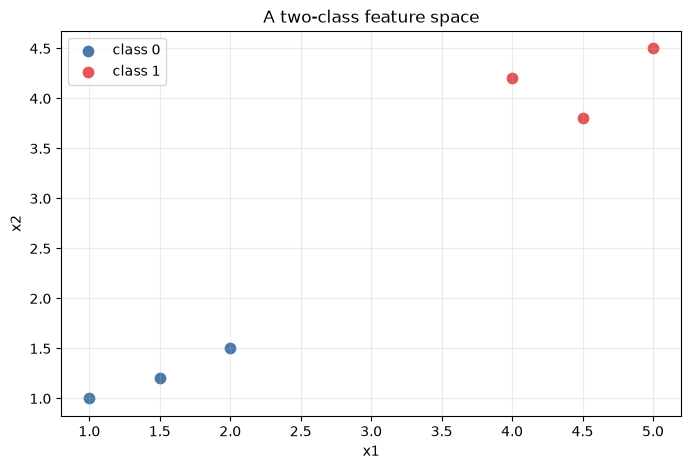

In [38]:
X = np.array([
    [1.0, 1.0],
    [1.5, 1.2],
    [2.0, 1.5],
    [4.0, 4.2],
    [4.5, 3.8],
    [5.0, 4.5],
])
y = np.array([0, 0, 0, 1, 1, 1])

fig, ax = plt.subplots()
ax.scatter(X[y == 0, 0], X[y == 0, 1], s=90, color="#4c78a8",
           edgecolor="white", label="class 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], s=90, color="#e45756",
           edgecolor="white", label="class 1")
ax.set(xlabel="x1", ylabel="x2", title="A two-class feature space")
ax.legend()
plt.show()


## Exercise 1 - One Perceptron Prediction

Complete the calculations for:

$$
z=\mathbf{w}^{\mathsf T}\mathbf{x}+b,\qquad
\hat y=\mathbb{1}[z>0].
$$

Use the values in the cell. Record the score and class before running the
encoded answer.


In [ ]:
x_one = np.array([2.0, 1.5])
w_one = np.array([0.4, -0.2])
b_one = -0.1

def perceptron_score(x, w, b):
    return w.T @ x + b

z_one =  perceptron_score(x_one,w_one,b_one)
z = w_one.T @ x_one +b_one 
print(z) 

if z_one > 0:
    prediction_one = 1
else:
    prediction_one =0 

print("score:", z_one)
print("prediction:", prediction_one)


0.4
score: 0.4
prediction: 1


## Exercise 2 - Weights Rotate; Bias Shifts

Run the visualization. Change one quantity at a time:

1. Keep w=[1, 1] and change only b.
2. Keep b=-3 and change the direction of w.
3. Describe the geometric effect of each change.


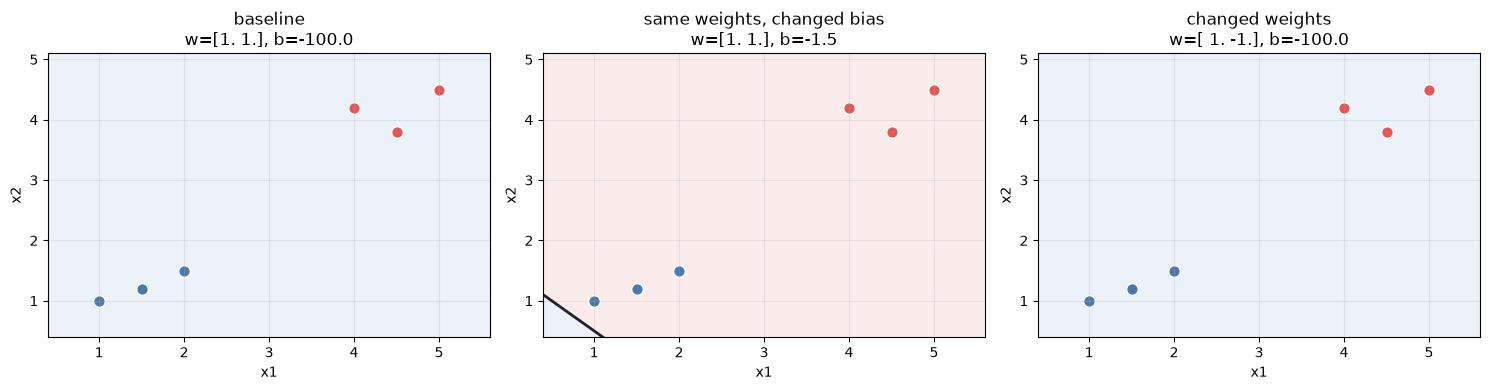

In [ ]:
experiments = [
    (np.array([1.0, 1.0]), -100.0, "baseline"),
    (np.array([1.0, 1.0]), -1.5, "same weights, changed bias"),
    (np.array([1.0, -1.0]), -100.0, "changed weights"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (w_trial, b_trial, label) in zip(axes, experiments):
    plot_boundary(X, y, w_trial, b_trial, ax,
                  f"{label}\nw={w_trial}, b={b_trial}")
plt.tight_layout()
plt.show()

#The bounded for x is 3 


## Exercise 3 - One Perceptron Update

Complete the function with the threshold prediction and the update:

$$
\mathbf{w}\leftarrow\mathbf{w}+\eta(t-\hat y)\mathbf{x},
\qquad
b\leftarrow b+\eta(t-\hat y).
$$

Leave parameters unchanged when the prediction is already correct.


In [ ]:
def perceptron_update(x, target, w, b, learning_rate):
    score = w.T @ x +b 
    prediction = None
    #Use 0 as threshold
    if score> 0:
        prediction =1
    else:
        prediction = 0

    error = target - prediction 

    w = w+learning_rate*error * X
    b = b+learning_rate *error

    # TODO: calculate error = target - prediction and update w and b.
    # Return the updated values.
    return w, b


## Exercise 4 - Train Across Epochs

Complete the training loop. One epoch processes all training examples once.
Store the weights and bias after every epoch so that the changing boundary can
be visualized.


In [49]:
def train_perceptron(X, target, learning_rate=0.2, epochs=20, seed=7):
    generator = np.random.default_rng(seed)
    w = generator.normal(scale=0.35, size=X.shape[1])
    b = float(generator.normal(scale=0.35))
    history = [(w.copy(), b)]
    mistakes = []

    for epoch in range(epochs):
        errors_this_epoch = 0
        for x_i, t_i in zip(X, target):
            prediction = None
            score = w.T @ x_i +b
            if score> 0:
                prediction = 1
            else:
                prediction = 0
            error = t_i -prediction

            if error != 0:
                w = w+learning_rate*error * X
                b = b+learning_rate *error
                errors_this_epoch +=1
        

    return w, b, history, np.array(mistakes)


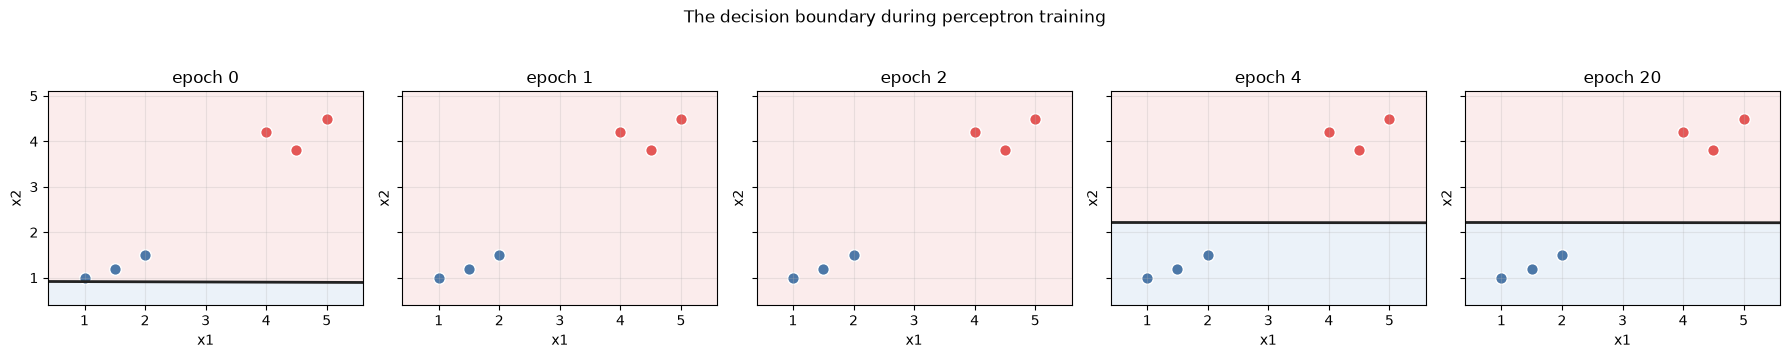

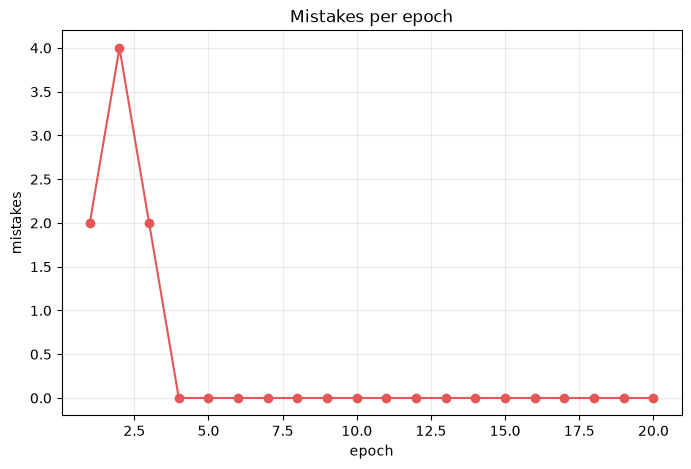

In [50]:
w_final, b_final, history, mistakes = reference_train_perceptron(X, y)
selected_epochs = [0, 1, 2, 4, len(history) - 1]

fig, axes = plt.subplots(1, len(selected_epochs), figsize=(18, 3.4), sharex=True, sharey=True)
for ax, epoch in zip(axes, selected_epochs):
    w_epoch, b_epoch = history[epoch]
    plot_boundary(X, y, w_epoch, b_epoch, ax, f"epoch {epoch}")
fig.suptitle("The decision boundary during perceptron training", y=1.04)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(mistakes) + 1), mistakes, "o-", color="#e45756")
ax.set(xlabel="epoch", ylabel="mistakes", title="Mistakes per epoch")
plt.show()


## Exercise 5 - Break the Perceptron with XOR

XOR has labels:

$$
(0,0)\mapsto0,\quad(0,1)\mapsto1,\quad
(1,0)\mapsto1,\quad(1,1)\mapsto0.
$$

Run the training cell. Explain why changing the learning rate cannot produce a
perfect single-perceptron solution.


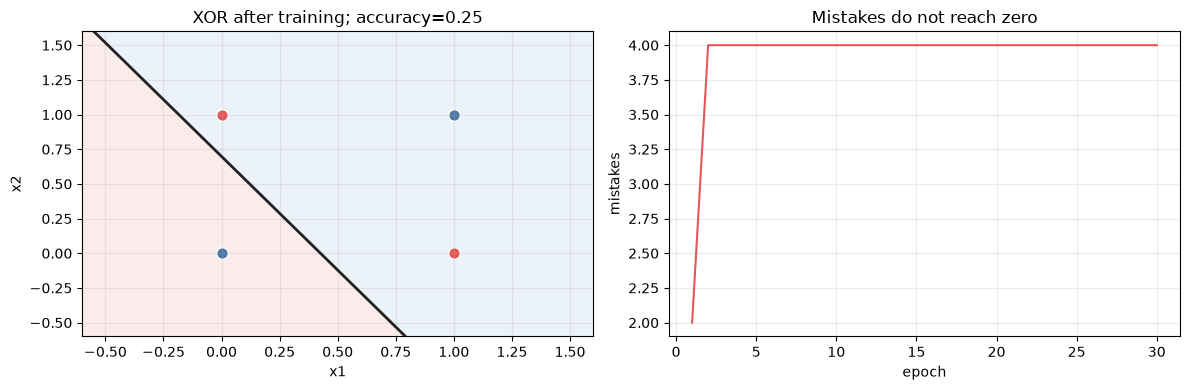

In [51]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])
w_xor, b_xor, history_xor, mistakes_xor = reference_train_perceptron(
    X_xor, y_xor, learning_rate=0.2, epochs=30, seed=4
)
xor_pred = (X_xor @ w_xor + b_xor > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_boundary(X_xor, y_xor, w_xor, b_xor, axes[0],
              f"XOR after training; accuracy={(xor_pred == y_xor).mean():.2f}")
axes[1].plot(np.arange(1, len(mistakes_xor) + 1), mistakes_xor, color="#e45756")
axes[1].set(xlabel="epoch", ylabel="mistakes", title="Mistakes do not reach zero")
plt.tight_layout()
plt.show()


### Encoded answer - Exercise 5


In [16]:
from base64 import b64decode

print(b64decode("WE9SIGlzIG5vdCBsaW5lYXJseSBzZXBhcmFibGUuIEEgc2luZ2xlIHBlcmNlcHRyb24gY2FuIG9ubHkgY3JlYXRlIG9uZSBzdHJhaWdodApkZWNpc2lvbiBib3VuZGFyeSwgYnV0IG5vIHN1Y2ggbGluZSBwbGFjZXMgYm90aCBwb3NpdGl2ZSBYT1IgY29ybmVycyBvbiBvbmUKc2lkZSBhbmQgYm90aCBuZWdhdGl2ZSBjb3JuZXJzIG9uIHRoZSBvdGhlci4gVGhlIGxpbWl0YXRpb24gaXMgcmVwcmVzZW50YXRpb25hbCwKc28gbGVhcm5pbmctcmF0ZSB0dW5pbmcgY2Fubm90IHNvbHZlIGl0Lg==").decode("utf-8"))


XOR is not linearly separable. A single perceptron can only create one straight
decision boundary, but no such line places both positive XOR corners on one
side and both negative corners on the other. The limitation is representational,
so learning-rate tuning cannot solve it.


## Mini Challenge - Which Datasets Are Linearly Separable?

Inspect the four feature spaces. Decide which can be perfectly classified with
one straight boundary before revealing the answer.


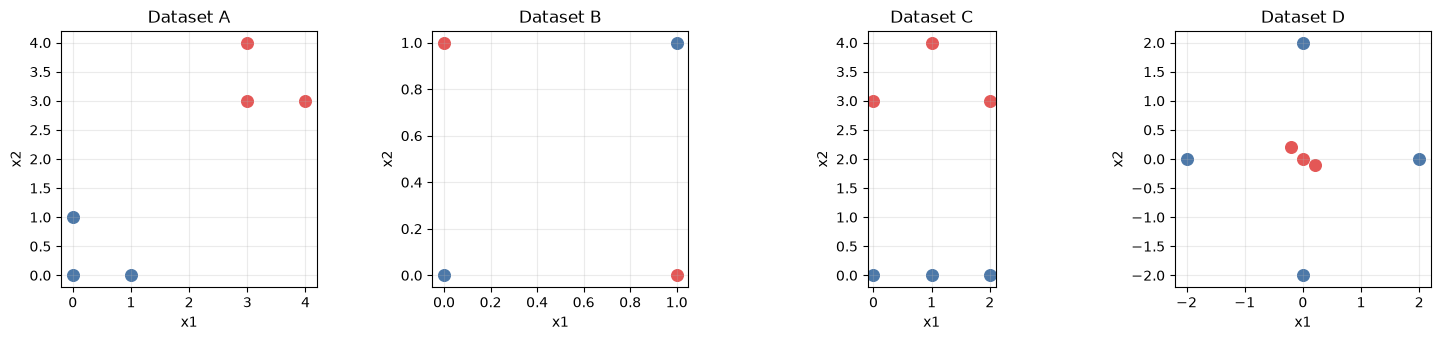

In [17]:
datasets = {
    "A": (np.array([[0, 0], [0, 1], [1, 0], [3, 3], [3, 4], [4, 3]]),
          np.array([0, 0, 0, 1, 1, 1])),
    "B": (X_xor, y_xor),
    "C": (np.array([[0, 0], [1, 0], [2, 0], [0, 3], [1, 4], [2, 3]]),
          np.array([0, 0, 0, 1, 1, 1])),
    "D": (np.array([[0, 0], [0.2, -0.1], [-0.2, 0.2], [2, 0], [-2, 0], [0, 2], [0, -2]]),
          np.array([1, 1, 1, 0, 0, 0, 0])),
}
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, (name, (X_set, y_set)) in zip(axes, datasets.items()):
    ax.scatter(X_set[y_set == 0, 0], X_set[y_set == 0, 1], s=70, color="#4c78a8")
    ax.scatter(X_set[y_set == 1, 0], X_set[y_set == 1, 1], s=70, color="#e45756")
    ax.set(title=f"Dataset {name}", xlabel="x1", ylabel="x2")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


### Encoded answer - Mini Challenge


In [18]:
from base64 import b64decode

print(b64decode("QSBhbmQgQyBhcmUgbGluZWFybHkgc2VwYXJhYmxlLiBCIGlzIFhPUiwgc28gaXRzIHBvc2l0aXZlIHBvaW50cyBsaWUgb24KZGlhZ29uYWwgY29ybmVycy4gRCBoYXMgb25lIGNsYXNzIHN1cnJvdW5kZWQgYnkgdGhlIG90aGVyIGNsYXNzLiBOZWl0aGVyIEIgbm9yCkQgY2FuIGJlIHNlcGFyYXRlZCBwZXJmZWN0bHkgYnkgb25lIGxpbmUu").decode("utf-8"))


A and C are linearly separable. B is XOR, so its positive points lie on
diagonal corners. D has one class surrounded by the other class. Neither B nor
D can be separated perfectly by one line.


# Part B - Make Linear Regression Learn a Line

The linear expression is unchanged:

$$
\hat y=wx+b.
$$

The important difference is that there is no threshold. The output remains a
numerical prediction.


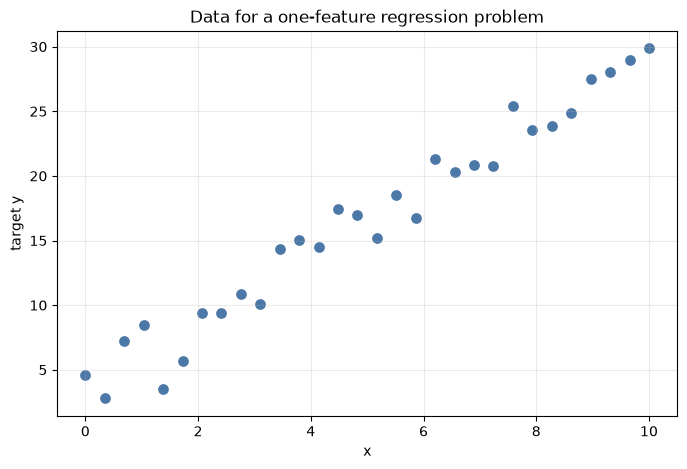

In [19]:
x_reg = np.linspace(0, 10, 30)
y_reg = 2.5 * x_reg + 4.0 + rng.normal(0, 2.0, size=x_reg.size)

fig, ax = plt.subplots()
ax.scatter(x_reg, y_reg, s=45, color="#4c78a8")
ax.set(xlabel="x", ylabel="target y", title="Data for a one-feature regression problem")
plt.show()


## Exercise 6 - Fit a Line by Eye

Add at least one plausible pair $(w,b)$ to the candidate list. Compare the
lines visually. Which line appears to leave the smallest vertical residuals?


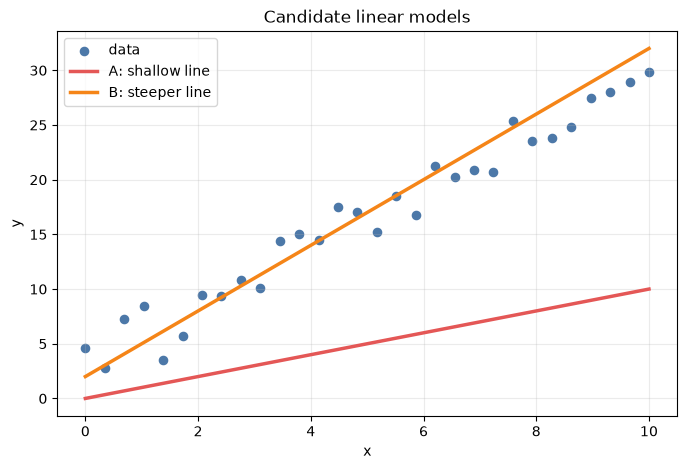

In [20]:
candidate_models = [
    (1.0, 0.0, "A: shallow line", "#e45756"),
    (3.0, 2.0, "B: steeper line", "#f58518"),
    # TODO: add a third candidate (weight, bias, label, color).
]

fig, ax = plt.subplots()
ax.scatter(x_reg, y_reg, color="#4c78a8", s=35, label="data")
for w_candidate, b_candidate, label, color in candidate_models:
    ax.plot(x_reg, w_candidate * x_reg + b_candidate, lw=2.5, color=color, label=label)
ax.set(xlabel="x", ylabel="y", title="Candidate linear models")
ax.legend()
plt.show()


### Encoded answer - Exercise 6


In [21]:
from base64 import b64decode

print(b64decode("T25lIHVzZWZ1bCBleHRyYSBjYW5kaWRhdGUgaXM6CgooMi41LCA0LjAsICJDOiB0cmVuZCBlc3RpbWF0ZSIsICIjNTRhMjRiIikKClRoZSBkYXRhIHdlcmUgZ2VuZXJhdGVkIGFyb3VuZCAyLjUqeCArIDQgd2l0aCByYW5kb20gbm9pc2UsIHNvIHRoaXMgbGluZSBpcyBhCnN0cm9uZyB2aXN1YWwgZXN0aW1hdGUuIEEgdmlzdWFsIGVzdGltYXRlIGlzIHVzZWZ1bCBpbnR1aXRpb24sIGJ1dCBhbiBvYmplY3RpdmUKZnVuY3Rpb24gaXMgbmVlZGVkIHRvIGNvbXBhcmUgbW9kZWxzIGNvbnNpc3RlbnRseS4=").decode("utf-8"))


One useful extra candidate is:

(2.5, 4.0, "C: trend estimate", "#54a24b")

The data were generated around 2.5*x + 4 with random noise, so this line is a
strong visual estimate. A visual estimate is useful intuition, but an objective
function is needed to compare models consistently.


## Exercise 7 - Implement Mean Squared Error

Complete the MSE function:

$$
\operatorname{MSE}=\frac{1}{N}\sum_j(y_j-\hat y_j)^2.
$$

Then compare the two candidate lines from Exercise 6.


In [22]:
def mse_task(y_true, y_pred):
    # TODO: return the mean of squared residuals.
    return None

prediction_a = 1.0 * x_reg + 0.0
prediction_b = 3.0 * x_reg + 2.0
print("MSE A:", mse_task(y_reg, prediction_a))
print("MSE B:", mse_task(y_reg, prediction_b))


MSE A: None
MSE B: None


### Encoded answer - Exercise 7


In [23]:
from base64 import b64decode

print(b64decode("ZGVmIG1zZV90YXNrKHlfdHJ1ZSwgeV9wcmVkKToKICAgIHJldHVybiBucC5tZWFuKCh5X3RydWUgLSB5X3ByZWQpICoqIDIpCgpNU0Ugc3F1YXJlcyByZXNpZHVhbHMgYmVmb3JlIGF2ZXJhZ2luZy4gVGhpcyBwcmV2ZW50cyBwb3NpdGl2ZSBhbmQgbmVnYXRpdmUKZXJyb3JzIGZyb20gY2FuY2VsbGluZyBhbmQgYXNzaWducyBncmVhdGVyIGNvc3QgdG8gYSBsYXJnZSBtaXNzLg==").decode("utf-8"))


def mse_task(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

MSE squares residuals before averaging. This prevents positive and negative
errors from cancelling and assigns greater cost to a large miss.


In [24]:
from base64 import b64decode

exec(b64decode("ZGVmIHJlZmVyZW5jZV9tc2UoeV90cnVlLCB5X3ByZWQpOgogICAgcmV0dXJuIG5wLm1lYW4oKHlfdHJ1ZSAtIHlfcHJlZCkgKiogMik=").decode("utf-8"), globals())


## Exercise 8 - Inspect the MSE Landscape

Fix $b=4$ and evaluate MSE for many possible weights. Identify the meaning of
the lowest point on the curve. This is the optimization target.


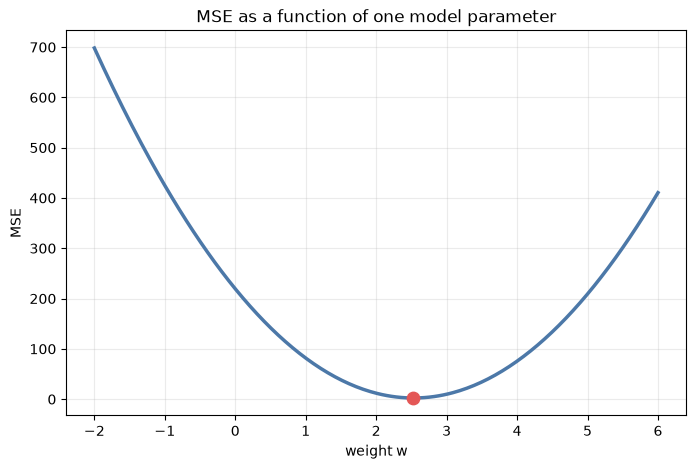

Best sampled weight with b fixed at 4: 2.519


In [25]:
b_fixed = 4.0
weights = np.linspace(-2, 6, 240)
mse_by_weight = np.array([
    reference_mse(y_reg, weight * x_reg + b_fixed)
    for weight in weights
])
best_index = np.argmin(mse_by_weight)

fig, ax = plt.subplots()
ax.plot(weights, mse_by_weight, color="#4c78a8", lw=2.5)
ax.scatter(weights[best_index], mse_by_weight[best_index], color="#e45756", s=80, zorder=3)
ax.set(xlabel="weight w", ylabel="MSE", title="MSE as a function of one model parameter")
plt.show()
print(f"Best sampled weight with b fixed at 4: {weights[best_index]:.3f}")


### Encoded answer - Exercise 8


In [26]:
from base64 import b64decode

print(b64decode("VGhlIGxvd2VzdCBwb2ludCBpcyB0aGUgd2VpZ2h0IHdpdGggdGhlIHNtYWxsZXN0IE1TRSBhbW9uZyB0aGUgc2FtcGxlZCB2YWx1ZXMuCldpdGggdGhlIGJpYXMgZml4ZWQsIG9wdGltaXphdGlvbiBpcyBhIG9uZS1kaW1lbnNpb25hbCBzZWFyY2ggb3ZlciB3LiBBbGxvd2luZwpib3RoIHcgYW5kIGIgdG8gdmFyeSBjcmVhdGVzIGEgdHdvLWRpbWVuc2lvbmFsIE1TRSBzdXJmYWNlLg==").decode("utf-8"))


The lowest point is the weight with the smallest MSE among the sampled values.
With the bias fixed, optimization is a one-dimensional search over w. Allowing
both w and b to vary creates a two-dimensional MSE surface.


## Exercise 9 - Gradient Descent from Scratch

For $\hat y=wx+b$, fill in the prediction, error, and two gradients:

$$
\frac{\partial MSE}{\partial w}=
\frac{2}{N}\sum_i(\hat y_i-y_i)x_i,
\qquad
\frac{\partial MSE}{\partial b}=
\frac{2}{N}\sum_i(\hat y_i-y_i).
$$

Update both parameters in the negative-gradient direction.


In [27]:
def gradient_descent_task(x, y, learning_rate=0.02, epochs=150):
    w, b = -1.0, 0.0
    history = []
    for epoch in range(epochs):
        # TODO: calculate prediction and error.
        # TODO: calculate grad_w and grad_b.
        # TODO: update w and b.
        # TODO: append (w, b, current_mse) to history.
        pass
    return w, b, history


### Encoded answer - Exercise 9


In [28]:
from base64 import b64decode

print(b64decode("ZGVmIGdyYWRpZW50X2Rlc2NlbnRfdGFzayh4LCB5LCBsZWFybmluZ19yYXRlPTAuMDIsIGVwb2Nocz0xNTApOgogICAgdywgYiA9IC0xLjAsIDAuMAogICAgaGlzdG9yeSA9IFtdCiAgICBmb3IgZXBvY2ggaW4gcmFuZ2UoZXBvY2hzKToKICAgICAgICBwcmVkaWN0aW9uID0gdyAqIHggKyBiCiAgICAgICAgZXJyb3IgPSBwcmVkaWN0aW9uIC0geQogICAgICAgIGN1cnJlbnRfbXNlID0gbnAubWVhbihlcnJvciAqKiAyKQogICAgICAgIGhpc3RvcnkuYXBwZW5kKCh3LCBiLCBjdXJyZW50X21zZSkpCiAgICAgICAgZ3JhZF93ID0gMiAqIG5wLm1lYW4oZXJyb3IgKiB4KQogICAgICAgIGdyYWRfYiA9IDIgKiBucC5tZWFuKGVycm9yKQogICAgICAgIHcgLT0gbGVhcm5pbmdfcmF0ZSAqIGdyYWRfdwogICAgICAgIGIgLT0gbGVhcm5pbmdfcmF0ZSAqIGdyYWRfYgogICAgcmV0dXJuIHcsIGIsIGhpc3Rvcnk=").decode("utf-8"))


def gradient_descent_task(x, y, learning_rate=0.02, epochs=150):
    w, b = -1.0, 0.0
    history = []
    for epoch in range(epochs):
        prediction = w * x + b
        error = prediction - y
        current_mse = np.mean(error ** 2)
        history.append((w, b, current_mse))
        grad_w = 2 * np.mean(error * x)
        grad_b = 2 * np.mean(error)
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b
    return w, b, history


In [29]:
from base64 import b64decode

exec(b64decode("ZGVmIHJlZmVyZW5jZV9ncmFkaWVudF9kZXNjZW50KHgsIHksIGxlYXJuaW5nX3JhdGU9MC4wMiwgZXBvY2hzPTE1MCk6CiAgICB3LCBiID0gLTEuMCwgMC4wCiAgICBoaXN0b3J5ID0gW10KICAgIGZvciBfIGluIHJhbmdlKGVwb2Nocyk6CiAgICAgICAgcHJlZGljdGlvbiA9IHcgKiB4ICsgYgogICAgICAgIGVycm9yID0gcHJlZGljdGlvbiAtIHkKICAgICAgICBjdXJyZW50X21zZSA9IG5wLm1lYW4oZXJyb3IgKiogMikKICAgICAgICBoaXN0b3J5LmFwcGVuZCgodywgYiwgY3VycmVudF9tc2UpKQogICAgICAgIGdyYWRfdyA9IDIgKiBucC5tZWFuKGVycm9yICogeCkKICAgICAgICBncmFkX2IgPSAyICogbnAubWVhbihlcnJvcikKICAgICAgICB3IC09IGxlYXJuaW5nX3JhdGUgKiBncmFkX3cKICAgICAgICBiIC09IGxlYXJuaW5nX3JhdGUgKiBncmFkX2IKICAgIHJldHVybiB3LCBiLCBucC5hcnJheShoaXN0b3J5KQ==").decode("utf-8"), globals())


## Exercise 10 - Watch the Line Learn

Run the cell and compare the line at early and late epochs. Relate the changing
line to the MSE curve on the right.


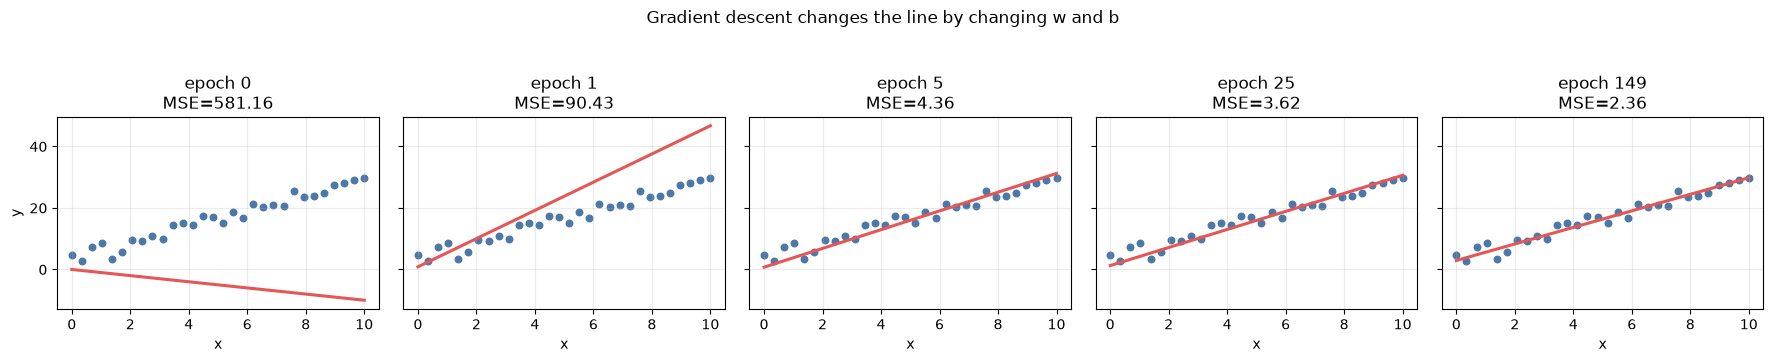

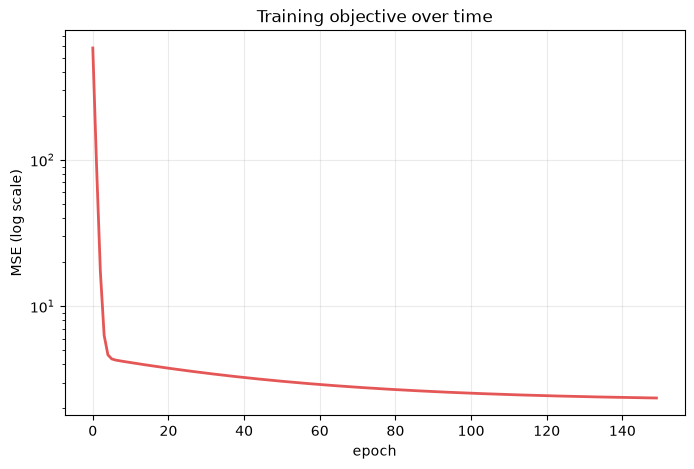

In [30]:
w_final, b_final, history_reg = reference_gradient_descent(x_reg, y_reg)
snapshots = [0, 1, 5, 25, len(history_reg) - 1]

fig, axes = plt.subplots(1, len(snapshots), figsize=(18, 3.4), sharex=True, sharey=True)
for ax, epoch in zip(axes, snapshots):
    w_epoch, b_epoch, loss_epoch = history_reg[epoch]
    ax.scatter(x_reg, y_reg, color="#4c78a8", s=22)
    ax.plot(x_reg, w_epoch * x_reg + b_epoch, color="#e45756", lw=2.2)
    ax.set(title=f"epoch {epoch}\nMSE={loss_epoch:.2f}", xlabel="x")
axes[0].set_ylabel("y")
fig.suptitle("Gradient descent changes the line by changing w and b", y=1.05)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.plot(history_reg[:, 2], color="#e45756", lw=2)
ax.set_yscale("log")
ax.set(xlabel="epoch", ylabel="MSE (log scale)", title="Training objective over time")
plt.show()


### Encoded answer - Exercise 10


In [31]:
from base64 import b64decode

print(b64decode("QXQgZmlyc3QsIHRoZSBsaW5lIGhhcyBhbiB1bnN1aXRhYmxlIHNsb3BlIGFuZCBpbnRlcmNlcHQsIHByb2R1Y2luZyBsYXJnZQpyZXNpZHVhbHMuIEVhY2ggZ3JhZGllbnQgc3RlcCBjaGFuZ2VzIHcgYW5kIGIgaW4gYSBkaXJlY3Rpb24gdGhhdCByZWR1Y2VzIE1TRS4KQXMgdGhlIGxpbmUgYXBwcm9hY2hlcyB0aGUgZGF0YSB0cmVuZCwgdGhlIE1TRSBkZWNyZWFzZXMgYW5kIHRoZSB1cGRhdGVzIGJlY29tZQpzbWFsbGVyIGluIGVmZmVjdC4=").decode("utf-8"))


At first, the line has an unsuitable slope and intercept, producing large
residuals. Each gradient step changes w and b in a direction that reduces MSE.
As the line approaches the data trend, the MSE decreases and the updates become
smaller in effect.


## Exercise 11 - Change the Learning Rate

Run the comparison. Explain the different curves for a very small, useful, and
excessively large learning rate.


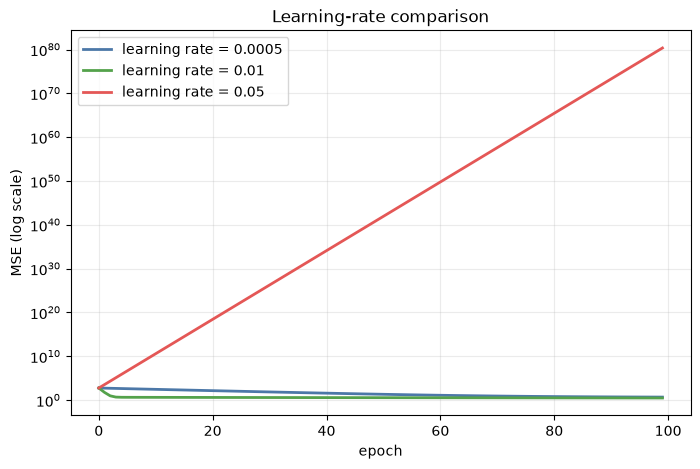

In [32]:
rates = [0.0005, 0.01, 0.05]
colors = ["#4c78a8", "#54a24b", "#e45756"]
fig, ax = plt.subplots()
for rate, color in zip(rates, colors):
    _, _, rate_history = reference_gradient_descent(
        x_reg, y_reg, learning_rate=rate, epochs=100
    )
    ax.plot(rate_history[:, 2], color=color, lw=2, label=f"learning rate = {rate}")
ax.set_yscale("log")
ax.set(xlabel="epoch", ylabel="MSE (log scale)", title="Learning-rate comparison")
ax.legend()
plt.show()


### Encoded answer - Exercise 11


In [33]:
from base64 import b64decode

print(b64decode("QSB0aW55IGxlYXJuaW5nIHJhdGUgbW92ZXMgaW4gYSB1c2VmdWwgZGlyZWN0aW9uIGJ1dCBuZWVkcyBtYW55IHVwZGF0ZXMuIEEKbW9kZXJhdGUgcmF0ZSBkZXNjZW5kcyBxdWlja2x5LiBBbiBleGNlc3NpdmVseSBsYXJnZSByYXRlIGNhbiBvdmVyc2hvb3QgdGhlCm1pbmltdW0gcmVwZWF0ZWRseTsgZm9yIHRoaXMgdW5zY2FsZWQgZGF0YXNldCBpdCBtYXkgbWFrZSB0aGUgbG9zcyBncm93LiBUaGUKZ3JhZGllbnQgc3VwcGxpZXMgZGlyZWN0aW9uLCB3aGlsZSB0aGUgbGVhcm5pbmcgcmF0ZSBzdXBwbGllcyBkaXN0YW5jZS4=").decode("utf-8"))


A tiny learning rate moves in a useful direction but needs many updates. A
moderate rate descends quickly. An excessively large rate can overshoot the
minimum repeatedly; for this unscaled dataset it may make the loss grow. The
gradient supplies direction, while the learning rate supplies distance.


## Exercise 12 - Matrix Form

Add a column of ones to represent the bias. Then calculate all predictions at
once:

$$
\hat Y=XW.
$$

Complete the two TODO lines and verify the shape of every array.


In [34]:
X_design = np.column_stack([np.ones_like(x_reg), x_reg])
W = np.array([4.0, 2.5])

# TODO: calculate all predictions with one matrix multiplication.
Y_prediction = None

# TODO: calculate the MSE with reference_mse.
matrix_mse = None

print("X shape:", X_design.shape)
print("W shape:", W.shape)
print("prediction shape:", None if Y_prediction is None else Y_prediction.shape)
print("MSE:", matrix_mse)


X shape: (30, 2)
W shape: (2,)
prediction shape: None
MSE: None


### Encoded answer - Exercise 12


In [35]:
from base64 import b64decode

print(b64decode("WV9wcmVkaWN0aW9uID0gWF9kZXNpZ24gQCBXCm1hdHJpeF9tc2UgPSByZWZlcmVuY2VfbXNlKHlfcmVnLCBZX3ByZWRpY3Rpb24pCgpYX2Rlc2lnbiBoYXMgc2hhcGUgKE4sIDIpOiBvbmUgYmlhcyBjb2x1bW4gYW5kIG9uZSBmZWF0dXJlIGNvbHVtbi4gVyBoYXMgc2hhcGUKKDIsKSwgc28gWF9kZXNpZ24gQCBXIGhhcyBvbmUgbnVtZXJpY2FsIHByZWRpY3Rpb24gZm9yIGVhY2ggb2YgdGhlIE4gcm93cy4KVGhpcyByZXBsYWNlcyBhbiBleHBsaWNpdCBsb29wIG92ZXIgb2JzZXJ2YXRpb25zLg==").decode("utf-8"))


Y_prediction = X_design @ W
matrix_mse = reference_mse(y_reg, Y_prediction)

X_design has shape (N, 2): one bias column and one feature column. W has shape
(2,), so X_design @ W has one numerical prediction for each of the N rows.
This replaces an explicit loop over observations.


## Final Mini Project - Classification or Regression?

Each observation contains two features: hours studied and attendance.

1. Target: passed or failed (0 or 1).
2. Target: exam score from 0 to 100.
3. Target: predicted number of study hours needed for a chosen score.

Choose a perceptron or linear regression for each target. State one limitation
that should be checked before relying on each selected model.


### Encoded answer - Final Mini Project


In [36]:
from base64 import b64decode

print(b64decode("MS4gUGFzc2VkIG9yIGZhaWxlZCBpcyBhIGNsYXNzaWZpY2F0aW9uIHRhc2ssIHNvIGEgcGVyY2VwdHJvbiBpcyB0aGUgcmVsZXZhbnQKICAgbW9kZWwgZnJvbSB0aGlzIGxlY3R1cmUuIEl0cyBtYWluIGxpbWl0YXRpb24gaXMgdGhhdCBvbmUgcGVyY2VwdHJvbiBjYW4gb25seQogICBmb3JtIGEgbGluZWFyIGRlY2lzaW9uIGJvdW5kYXJ5LgoKMi4gRXhhbSBzY29yZSBpcyBhIGNvbnRpbnVvdXMgbnVtZXJpY2FsIHRhcmdldCwgc28gbGluZWFyIHJlZ3Jlc3Npb24gaXMgdGhlCiAgIHJlbGV2YW50IG1vZGVsLiBJdHMgbWFpbiBsaW1pdGF0aW9uIGlzIHRoZSBsaW5lYXItZnVuY3Rpb24gYXNzdW1wdGlvbjsgYQogICBjdXJ2ZWQgcmVsYXRpb25zaGlwIG1heSBuZWVkIHRyYW5zZm9ybWVkIGZlYXR1cmVzIG9yIGEgZGlmZmVyZW50IG1vZGVsLgoKMy4gUmVxdWlyZWQgc3R1ZHkgaG91cnMgaXMgYWxzbyBudW1lcmljYWwsIHNvIGl0IGlzIGEgcmVncmVzc2lvbiB0YXNrLiBBCiAgIHByZWRpY3Rpb24gY2FuIGZhbGwgb3V0c2lkZSBhIG1lYW5pbmdmdWwgcmFuZ2UsIHNvIHBsYXVzaWJsZSBib3VuZHMgYW5kCiAgIHJlc2lkdWFsIGJlaGF2aW91ciBzaG91bGQgYmUgY2hlY2tlZC4=").decode("utf-8"))


1. Passed or failed is a classification task, so a perceptron is the relevant
   model from this lecture. Its main limitation is that one perceptron can only
   form a linear decision boundary.

2. Exam score is a continuous numerical target, so linear regression is the
   relevant model. Its main limitation is the linear-function assumption; a
   curved relationship may need transformed features or a different model.

3. Required study hours is also numerical, so it is a regression task. A
   prediction can fall outside a meaningful range, so plausible bounds and
   residual behaviour should be checked.


## Practice Summary

The same weighted sum $w\cdot x+b$ can serve two different purposes. A
threshold makes it a perceptron classifier. Keeping its numerical value makes
it a linear-regression predictor. Training connects prediction errors to
parameter updates; the selected objective determines what "better" means.
